In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np

mit_train = pd.read_csv('archive/mitbih_train.csv',header=None)
mit_test = pd.read_csv('archive/mitbih_test.csv',header=None)
ptb_normal = pd.read_csv('archive/ptbdb_normal.csv',header=None)
ptb_abnormal = pd.read_csv('archive/ptbdb_abnormal.csv',header=None)

(87554, 188)
0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
87549    4.0
87550    4.0
87551    4.0
87552    4.0
87553    4.0
Name: 187, Length: 87554, dtype: float64
[0. 0. 0. ... 4. 4. 4.]
87554
(87554, 187)
(21892, 187)
data printing 0.9322328567504883
            0         1         2         3         4         5         6    \
0      0.932233  0.869679  0.886186  0.929626  0.908775  0.933970  0.801043   
1      1.000000  0.606941  0.384181  0.254237  0.223567  0.276836  0.253430   
2      1.000000  0.951613  0.923963  0.853303  0.791859  0.734255  0.672043   
3      0.977819  0.899261  0.230129  0.032348  0.142329  0.223660  0.328096   
4      0.935618  0.801661  0.805815  1.000000  0.722741  0.480789  0.454829   
...         ...       ...       ...       ...       ...       ...       ...   
10501  0.981409  1.000000  0.559171  0.287093  0.196639  0.204862  0.215946   
10502  0.906250  0.922379  0.878024  0.810484  0.712702  0.667339  0.608871   
105

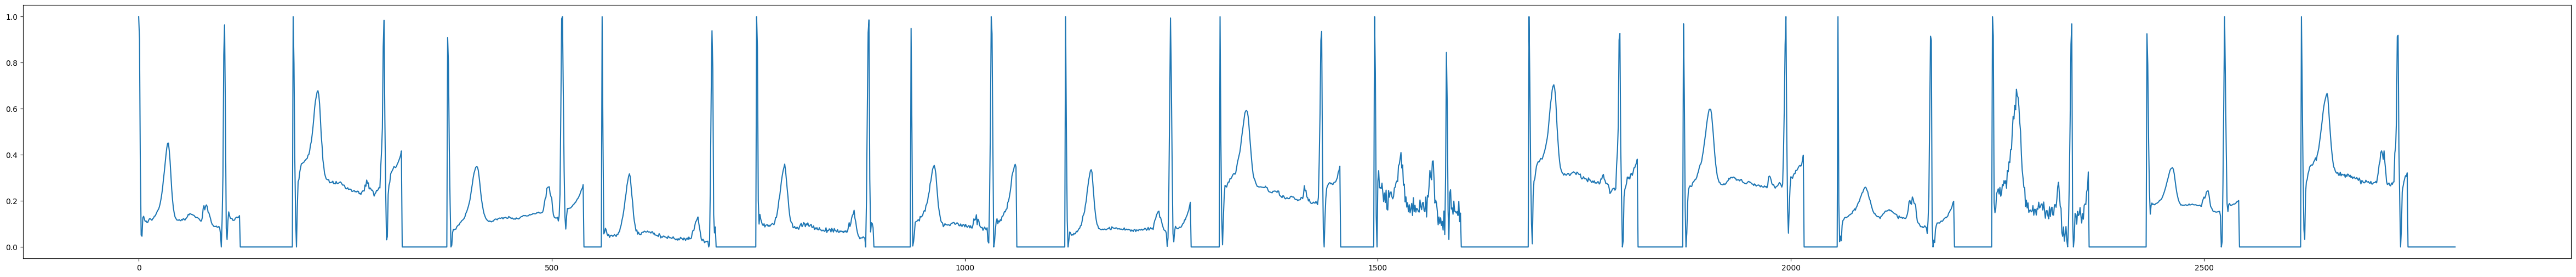

In [3]:
import matplotlib.pyplot as plt
print(mit_train.shape)
# print(mit_train[187])
# mit_train[187]=mit_train[187].astype(int)
print(mit_train[187])
print(np.asarray(mit_train[187]))
mit_train_labels=np.asarray(mit_train[187])
mit_test_labels=np.asarray(mit_test[187])

print(len(mit_train_labels))
mit_train_data = np.asarray(mit_train)
# print(mit_train_data[:,-2])
mit_train_data = mit_train_data[:,:-1]
print(mit_train_data.shape)
mit_test_data = np.asarray(mit_test)
# print(mit_train_data[:,-2])
mit_test_data = mit_test_data[:,:-1]

print(mit_test_data.shape)
# plt.plot(mit_test_data[0])
# plt.plot(mit_train_data[0] + np.random.normal(0,0.5,187))
# mit_test_labels=np.asarray(mit_test[187])
# print(len(mit_test_labels))


ptb_normal_data = np.asarray(ptb_normal).astype(np.float32)
# print(mit_train_data[:,-2])
ptb_normal_data = ptb_normal_data[:,:-1]


ptb_abnormal_data = np.asarray(ptb_abnormal)
print("data printing", ptb_abnormal_data[0][0])
temp = []
for i in range(15):
    for j in range(len(ptb_normal_data[0])):
        temp.append(ptb_normal_data[i][j])

temp = np.array(temp)
plt.figure(figsize=(60,6))
plt.plot(temp)

# plt.plot(ptb_abnormal_data[0])
ptb_abnormal_df = pd.DataFrame(ptb_abnormal_data)
print(ptb_abnormal_df, ptb_abnormal_df.size)
row = ptb_abnormal_df.iloc[0]
rows_concat = pd.concat([ptb_abnormal_df.iloc[0:1], ptb_abnormal_df.iloc[2:3]], ignore_index = True)
rows_concat.reset_index(drop=True, inplace=True)
# plt.plot(rows_concat.index, rows_concat.values, marker = 'o', label = 'Row 0 data')
# concat_data = []
# for i in range(len(ptb_abnormal_data)):
#     concat_data.append(pd.DataFrame(ptb_abnormal_data[i]))

# concat_ptb_abnormal_data = pd.concat(concat_data, ignore_index = True)
# plt.plot(concat_ptb_abnormal_data[0])
               
# print(mit_train_data[:,-2])
ptb_abnormal_data = ptb_abnormal_data[:,:-1]





(256,)


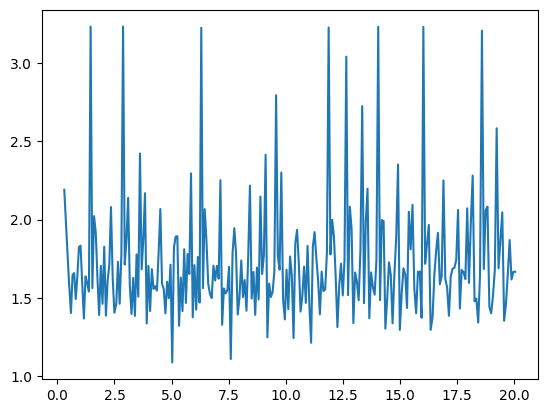

In [4]:
with open('results11.npy', 'rb') as f:
    X_data = np.load(f)
    Y_data = np.load(f)

print(X_data.shape)
plt.plot(X_data, Y_data)


[1.         0.7946815  0.3753865  0.11688311 0.         0.17192331
 0.28385898 0.29375386 0.32591218 0.34508348 0.3617811  0.36239952
 0.3661101  0.36796537 0.37414965 0.37786025 0.38218924 0.38466296
 0.39888683 0.40136054 0.41805813 0.44341373 0.4576376  0.48794064
 0.5207174  0.55967844 0.6042053  0.6345084  0.65367967 0.67285097
 0.67841685 0.66048235 0.62152135 0.55596787 0.48237476 0.4384663
 0.37847868 0.35126778 0.3197279  0.30674088 0.29560915 0.29313543
 0.29189858 0.292517   0.27891156 0.27891156 0.28076684 0.28076684
 0.2857143  0.27458256 0.275201   0.27396414 0.2844774  0.27643785
 0.275201   0.2776747  0.27953    0.28262213 0.27953    0.2733457
 0.26839826 0.26901668 0.26777983 0.25726655 0.2523191  0.25293753
 0.25726655 0.24984539 0.25108224 0.25108224 0.24984539 0.2418058
 0.24118738 0.2436611  0.24489796 0.2393321  0.2418058  0.23871367
 0.24242425 0.24118738 0.23067409 0.23252937 0.22820038 0.23747681
 0.24304268 0.2436611  0.24304268 0.26901668 0.26345083 0.2906617

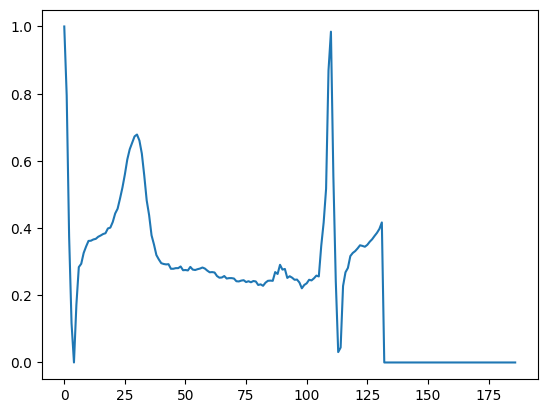

In [5]:
plt.plot(ptb_normal_data[1])
print(ptb_normal_data[1])

In [6]:

from tensorflow.keras.layers import Dense, Flatten, Conv2D,Conv1D,Input

mit_train_labels=np.asarray(mit_train[187])

mit_train_data=mit_train_data.reshape(mit_train_data.shape[0],mit_train_data.shape[1],1)

# print(mit_train_data.shape)

mit_train_labels = mit_train_labels.reshape(mit_train_labels.shape[0],1)

# print(mit_train_labels.shape)
# print(mit_train_labels)

mit_train_labels2 = np.zeros((len(mit_train_labels),5))

# print(mit_train_labels2.shape)

for i in range(len(mit_train_labels)):
    ind = int(mit_train_labels[i][0])
    mit_train_labels2[i][ind] = 1

# print(mit_train_labels2)

# print(mit_train_data[0][85])




mit_test_labels=np.asarray(mit_test[187])

mit_test_data=mit_test_data.reshape(mit_test_data.shape[0],mit_test_data.shape[1],1)

print(mit_test_data.shape)

mit_test_labels = mit_test_labels.reshape(mit_test_labels.shape[0],1)

print(mit_test_labels.shape)
print(mit_test_labels)

mit_test_labels2 = np.zeros((len(mit_test_labels),5))

print(mit_test_labels2.shape)

for i in range(len(mit_test_labels)):
    ind = int(mit_test_labels[i][0])
    mit_test_labels2[i][ind] = 1
print(mit_train_labels2)




(21892, 187, 1)
(21892, 1)
[[0.]
 [0.]
 [0.]
 ...
 [4.]
 [4.]
 [4.]]
(21892, 5)
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [9]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D,Conv1D, MaxPool1D, BatchNormalization,Dropout

# c= mit_train.groupby(187,group_keys=False).apply(lambda mit_train : mit_train.sample(1))

# ecgShape=(mit_train_data[1].shape)
# inputLayer=Input(shape=(ecgShape), name='input_layer')
#  input_shape=ecgShape,
conv1_1 = Conv1D(64, (6), activation='relu',name = 'conv1_1')
pool1=MaxPool1D(pool_size=(3), strides=(2), padding="same",name='pooling1')
conv1_2=Conv1D(64, (3), activation='relu', name='conv1_2')
# conv2_1=BatchNormalization()(conv2_1)
pool2=MaxPool1D(pool_size=(2), strides=(2), padding="same",name='pooling2')
conv1_3=Conv1D(64, (3), activation='relu',name='conv1_3')
# conv3_1=BatchNormalization()(conv3_1)
pool3=MaxPool1D(pool_size=(2), strides=(2), padding="same",name='pooling3')
flatten_data = tf.keras.layers.Flatten()

SequentialDense = keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu", name="Denselayer1"),
        tf.keras.layers.Dense(32, activation="relu", name="Denselayer2"),
        tf.keras.layers.Dense(5, activation = "softmax", name="Denselayer3"),
    ],name='denseSequentials'
)


model = tf.keras.Sequential([BatchNormalization(),(conv1_1), pool1, BatchNormalization(),(conv1_2), 
                             pool2, BatchNormalization(),(conv1_3), pool3, Dropout(0.3),flatten_data, SequentialDense])
model2 = model
model2.build((1,187,1))
model2.summary()

model.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
training_result  = model.fit(
    x=mit_train_data,
    y=mit_train_labels2,
    batch_size=32,
    epochs=25,
    verbose="auto",
    callbacks=None,
    validation_split= float(1/7),
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1,
)



    

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_6 (Batc  (1, 187, 1)              4         
 hNormalization)                                                 
                                                                 
 conv1_1 (Conv1D)            (1, 182, 64)              448       
                                                                 
 pooling1 (MaxPooling1D)     (1, 91, 64)               0         
                                                                 
 batch_normalization_7 (Batc  (1, 91, 64)              256       
 hNormalization)                                                 
                                                                 
 conv1_2 (Conv1D)            (1, 89, 64)               12352     
                                                                 
 pooling2 (MaxPooling1D)     (1, 45, 64)              

In [10]:
train_accuracy = training_result.history['accuracy'][-1]

loss, accuracy = model.evaluate(
    x=mit_test_data,
    y=mit_test_labels2,
    # batch_size=64,
    verbose=1,
    # sample_weight=None,
    steps=None,
    # callbacks=None,
    # return_dict=False,
)
print(train_accuracy)
print(accuracy)


print(loss)
model.save("MITModel")

685/685 [==============================] - 3s 5ms/step - loss: 10.7431 - accuracy: 0.8982
0.9963355660438538
0.8982276916503906
10.743086814880371


INFO:tensorflow:Assets written to: MITModel\assets


INFO:tensorflow:Assets written to: MITModel\assets


In [11]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D,Conv1D, MaxPool1D, BatchNormalization,Dropout
from sklearn.model_selection import train_test_split

print("hello")


normal_train, normal_test = train_test_split(ptb_normal_data, test_size=0.15, random_state=45, shuffle=True)
print(normal_train.shape)

hello
(3439, 187)


In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D,Conv1D, MaxPool1D, BatchNormalization,Dropout
from sklearn.model_selection import train_test_split

print("hello")



original_train, original_test = train_test_split(ptb_normal_data, test_size=0.10, random_state=45, shuffle=True)
normal_train, normal_test = train_test_split(original_train, test_size=0.11, random_state=45, shuffle=True)
# normal_train = 0
# normal_test = 0

latent_dim = 32
conv21_1 = Conv1D(128, 3 ,strides=1,  activation='relu' , padding="same", name = "conv_layer_1")
pool21_2 = MaxPool1D(2, padding="same",  name = "pooling_layer_1")
conv21_2 = Conv1D(128, 3, strides=1, activation='relu', padding="same" , name = "conv_layer_2")
pool21_3 = MaxPool1D(2, padding="same" ,  name = "pooling_layer_2")
conv23_3 = Conv1D(latent_dim, 3, strides=1, activation='relu', padding="same" , name = "conv_layer_3")

coded_layer = MaxPool1D(2, padding="same", name = "coded_layer")


conv_t1 = tf.keras.layers.Conv1DTranspose(latent_dim, 3, strides=1, activation='relu', padding="same" , name = "conv_transpose_layer_1")
# pool_up1 = tf.keras.layers.UpSampling1D(2)
conv_t2 = tf.keras.layers.Conv1DTranspose(128, 3, strides=1, activation='relu', padding="same",  name = "conv_transpose_layer_2")
# pool_up2 = tf.keras.layers.UpSampling1D(2)
conv_t3 = tf.keras.layers.Conv1DTranspose(128, 3, strides=1, activation='relu', padding="same",  name = "conv_transpose_layer_3")
# pool_up3 = tf.keras.layers.UpSampling1D(2)
flatten_data2 = tf.keras.layers.Flatten()
SequentialDense2 = tf.keras.layers.Dense(187, activation="relu", name="Denselayer1")
# SequentialDense3 = tf.keras.layers.Dense(187, activation="relu", name="Denselayer2")
# SequentialDense4 = tf.keras.layers.Dense(187, activation="relu", name="Denselayer3")

# model_encoder = tf.keras.Sequential([BatchNormalization(),(conv21_1), pool21_2, BatchNormalization(),(conv21_2), 
#                              pool21_3, BatchNormalization(),(conv23_3)])

# model_decoder = tf.keras.Sequential([BatchNormalization(),(conv_t1),
#                              BatchNormalization(),(conv_t2), BatchNormalization(),(conv_t3),
#                              Dropout(0.3),flatten_data2, SequentialDense2])

completed_model = tf.keras.Sequential([BatchNormalization(),(conv21_1), pool21_2, BatchNormalization(),(conv21_2), 
                             pool21_3, BatchNormalization(),(conv23_3), coded_layer, BatchNormalization(),(conv_t1),
                             BatchNormalization(),(conv_t2), BatchNormalization(),(conv_t3),
                             Dropout(0.3),flatten_data2, SequentialDense2])
model_test = completed_model
model_test.build((1,187,1))
model_test.summary()

completed_model.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['accuracy'],
)
training_result_2  = completed_model.fit(
    x=normal_train,
    y=normal_train,
    batch_size=32,
    epochs= 30,
    verbose="auto",
    callbacks=None,
    validation_data= (normal_test, normal_test),
    shuffle=False,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1,
)
      

In [20]:
completed_model.save("anomaly_detection_model")

INFO:tensorflow:Assets written to: anomaly_detection_model\assets


INFO:tensorflow:Assets written to: anomaly_detection_model\assets


In [ ]:
plt.plot(training_result_2.history["loss"], label="Training Loss")
plt.plot(training_result_2.history["val_loss"], label="Validation Loss")
plt.legend()

In [ ]:
# autoencoder with only dense layers

encoder_three = tf.keras.Sequential([tf.keras.layers.Dense(32, activation = "relu"), 
                                     tf.keras.layers.Dense(16, activation = "relu"), 
                                     tf.keras.layers.Dense(8, activation = "relu")])

decoder_three = tf.keras.Sequential([tf.keras.layers.Dense(16, activation = "relu"), 
                                     tf.keras.layers.Dense(32, activation = "relu"), 
                                     tf.keras.layers.Dense(187, activation = "sigmoid"), ])

model_three = tf.keras.Sequential([encoder_three, decoder_three])

# split the data into train and test
normal_train3, normal_test3 = train_test_split(ptb_normal_data, test_size=0.10, random_state=45, shuffle=True)
ptb_normal_train_data, ptb_normal_test_data = train_test_split(normal_train3, test_size= 0.12, random_state= 21, shuffle = True)
min_val_three = tf.reduce_min(ptb_normal_train_data)
max_val_three = tf.reduce_max(ptb_normal_train_data)


# normalize the data
ptb_normal_train_data = (ptb_normal_train_data - min_val_three) / (max_val_three - min_val_three)
ptb_normal_test_data = (ptb_normal_test_data - min_val_three) /(max_val_three - min_val_three)

model_three.compile(optimizer='adam', loss = 'mae')
history_three = model_three.fit(ptb_normal_train_data, ptb_normal_train_data,
                                epochs = 100,
                                batch_size = 512,
                                validation_data = (ptb_normal_test_data, ptb_normal_test_data),
                                shuffle = False)

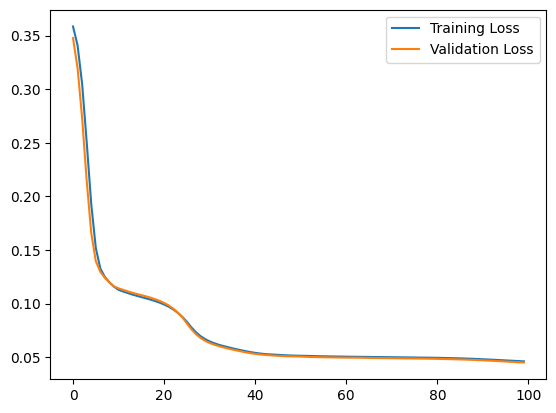

In [24]:
plt.plot(history_three.history["loss"], label="Training Loss")
plt.plot(history_three.history["val_loss"], label="Validation Loss")
plt.legend()




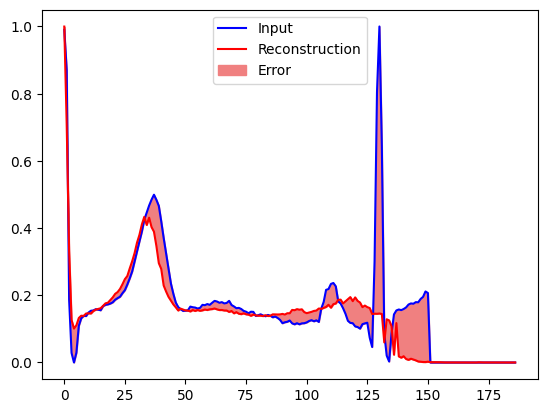

In [25]:
encoded_data3 = encoder_three(ptb_normal_test_data).numpy()
decoded_data3 = decoder_three(encoded_data3).numpy()
# decoded_data3 = autoencoder.decoder(encoded_data).numpy()

plt.plot(ptb_normal_test_data[0], 'b')
plt.plot(decoded_data3[0], 'r')
plt.fill_between(np.arange(187), decoded_data3[0], ptb_normal_test_data[0], color='lightcoral')
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()

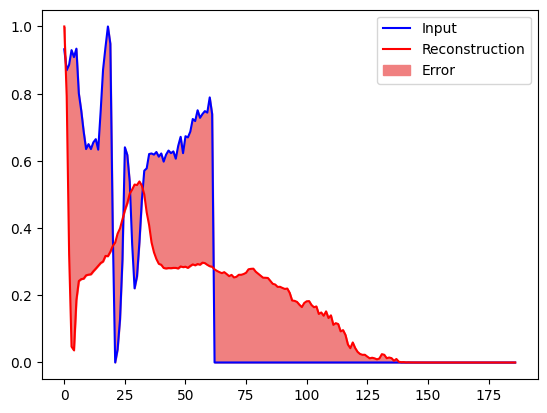

In [26]:
encoded_data3 = encoder_three(ptb_abnormal_data).numpy()
decoded_data3 = decoder_three(encoded_data3).numpy()
# decoded_data3 = autoencoder.decoder(encoded_data).numpy()

plt.plot(ptb_abnormal_data[0], 'b')
plt.plot(decoded_data3[0], 'r')
plt.fill_between(np.arange(187), decoded_data3[0], ptb_abnormal_data[0], color='lightcoral')
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()

101/101 [==============================] - 0s 2ms/step


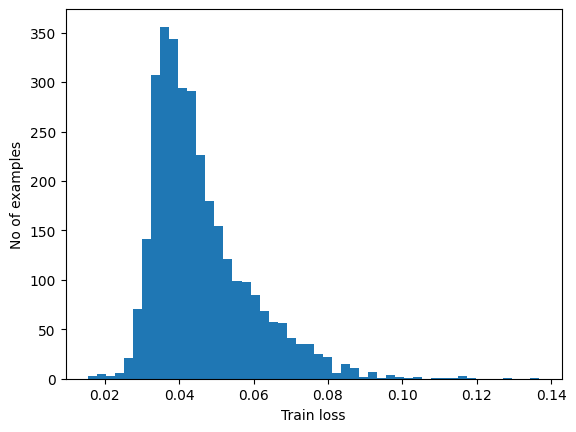

Threshold:  0.059261546


In [27]:
reconstruction = model_three.predict(ptb_normal_train_data)
train_loss3 = tf.keras.losses.mae(reconstruction, ptb_normal_train_data)
plt.hist(train_loss3[None,:], bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

threshold3 = np.mean(train_loss3) + np.std(train_loss3)
print("Threshold: ", threshold3)

329/329 [==============================] - 1s 2ms/step


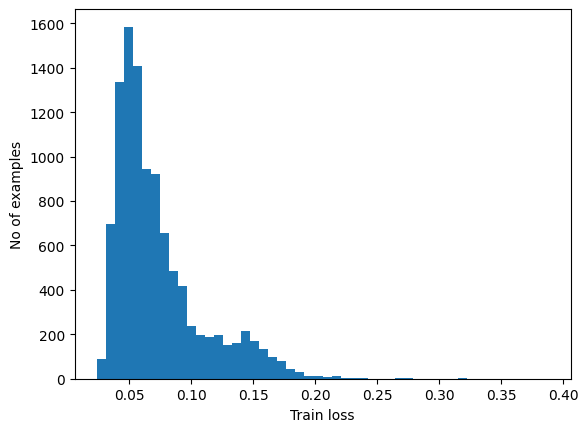

Threshold:  0.10933206117226338


In [28]:
reconstruction = model_three.predict(ptb_abnormal_data)
test_loss3 = tf.keras.losses.mae(reconstruction, ptb_abnormal_data)
plt.hist(test_loss3[None,:], bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

threshold3 = np.mean(test_loss3) + np.std(test_loss3)
print("Threshold: ", threshold3)

In [29]:
# def predict(model, data, threshold):
#   reconstructions = model(data)
#   loss = tf.keras.losses.mae(reconstructions, data)
#   return tf.math.less(loss, threshold)

# def print_stats(predictions, labels):
#   print("Accuracy = {}".format(accuracy_score(labels, predictions)))
#   print("Precision = {}".format(precision_score(labels, predictions)))
#   print("Recall = {}".format(recall_score(labels, predictions)))

# preds3 = predict(autoencoder, test_data, threshold)
# print_stats(preds3, test_labels)



def prediction(model, data):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return reconstructions, loss

guess3, training_loss3 = prediction(model_three, ptb_normal_train_data)
print(type(training_loss3))
print(training_loss3)
threshold = np.mean(training_loss3) + np.std(training_loss3)



def evaluate_model_complete(model, data):
    pred, loss = prediction(model, data)
    accuracy_abnormal = 0
    accuracy_normal= 0

    for l in loss:
        if l > threshold:
            accuracy_abnormal += 1
        elif l <= threshold:
            accuracy_normal += 1

    if id(data) == id(ptb_abnormal_data):
        accuracy = accuracy_abnormal/len(data)
    else: 
        accuracy = accuracy_normal/len(data)
    
    # if id(data) == id(ptb_abnormal_data):
    #     accuracy = np.sum(loss > threshold)/len(data)
    # else:
    #     accuracy = np.sum(loss <= threshold)/len(data)
    return f"Accuracy: {accuracy:.2%}"

output = evaluate_model_complete(model_three, ptb_normal_train_data)
output2 = evaluate_model_complete(model_three, normal_test3)
output3 = evaluate_model_complete(model_three, ptb_abnormal_data)
print(output, output2, output3)

<class 'tensorflow.python.framework.ops.EagerTensor'>
tf.Tensor([0.05247236 0.05243987 0.03668571 ... 0.05086942 0.03941555 0.0686666 ], shape=(3204,), dtype=float32)
Accuracy: 84.93% Accuracy: 84.69% Accuracy: 53.19%


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from datetime import datetime

ptb_normal_data = np.asarray(ptb_normal)
ptb_normal_data = ptb_normal_data[:,:-1]
plt.figure(figsize = (10,4))
dates = pd.date_range(start=0, periods=ptb_normal_data.shape[0:10, :], freq='M')
time_series = pd.Series(ptb_normal_data[0:10, :])

period = 12
plt.plot(time_series)
print(ptb_normal_data.shape)
stl = STL(time_series, period = period, seasonal = 13)
result = stl.fit()



In [ ]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid

plt.figure(figsize=(8,6))

plt.subplot(4,1,1)
plt.plot(time_series)
plt.title('Original Series', fontsize=16)

plt.subplot(4,1,2)
plt.plot(trend)
plt.title('Trend', fontsize=16)

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title('Seasonal', fontsize=16)

plt.subplot(4,1,4)
plt.plot(resid)
plt.title('Residual', fontsize=16)

plt.tight_layout()

In [25]:
def prediction(model, data):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return reconstructions, loss

guess, training_loss = prediction(completed_model, normal_train)
print(type(training_loss))
print(training_loss)
threshold = np.mean(training_loss) + np.std(training_loss)



def evaluate_model_complete(model, data):
    pred, loss = prediction(model, data)
    accuracy_abnormal = 0
    accuracy_normal= 0

    for l in loss:
        if l > threshold:
            accuracy_abnormal += 1
        elif l <= threshold:
            accuracy_normal += 1

    if id(data) == id(ptb_abnormal_data):
        accuracy = accuracy_abnormal/len(data)
    else: 
        accuracy = accuracy_normal/len(data)
    
    # if id(data) == id(ptb_abnormal_data):
    #     accuracy = np.sum(loss > threshold)/len(data)
    # else:
    #     accuracy = np.sum(loss <= threshold)/len(data)
    return f"Accuracy: {accuracy:.2%}"

output = evaluate_model_complete(completed_model, normal_train)
output2 = evaluate_model_complete(completed_model, original_test)
output3 = evaluate_model_complete(completed_model, ptb_abnormal_data)
print(output, output2, output3)



<class 'tensorflow.python.framework.ops.EagerTensor'>
tf.Tensor([0.02623949 0.01109005 0.01407735 ... 0.01584644 0.0136598  0.0126647 ], shape=(3240,), dtype=float64)
Accuracy: 86.91% Accuracy: 85.19% Accuracy: 73.34%


In [26]:
converter = tf.lite.TFLiteConverter.from_saved_model("anomaly_detection_model")
tflite_model = converter.convert()

with open('modelPart3.tflite', 'wb') as f:
  f.write(tflite_model)

In [ ]:
with open('results11.npy', 'rb') as f:
    X_data = np.load(f)
    Y_data = np.load(f) 

print(X_data.shape)
# plt.figure(figsize=(30,6))


X_data = X_data[0:187]
Y_data = Y_data[0:187]
Y_data = Y_data/ (np.max(Y_data))
Y_data = np.array(Y_data).astype(np.float32)
X_data = np.array(X_data).astype(np.float32)
# plt.plot(X_data, Y_data)
result = np.array([X_data, Y_data], dtype=np.float32)
result = np.expand_dims(result, axis=0)
Y_data = Y_data.reshape((1, len(Y_data), 1))

# plt.plot(Y_data)
# test1 = evaluate_model_complete(completed_model, Y_data)

def run_model(data, interpreter):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    interpreter.set_tensor(input_details[0]['index'],data )
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])

    return output_data
 

tfl_file = "./modelPart3.tflite"
interpreter = tf.lite.Interpreter(model_path = tfl_file)
interpreter.allocate_tensors()

output_tensor1 = run_model(Y_data, interpreter)
print(output_tensor1)
plt.plot(output_tensor1)

In [ ]:
#ltsm encoder
model_ltsm = tf.keras.Sequential([tf.keras.layers.LSTM(32, activation = 'relu', input_shape = (187,1), return_sequences= True),
                                  tf.keras.layers.LSTM(16, activation='relu', return_sequences=False),
                                  tf.keras.layers.RepeatVector(187),
                                  tf.keras.layers.LSTM(16, activation='relu', return_sequences=True),
                                  tf.keras.layers.LSTM(32, activation='relu', return_sequences=True),
                                  tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))])

model_ltsm.compile(optimizer='adam' , loss = 'mae')

history_lstm = model_ltsm.fit(ptb_normal_train_data, ptb_normal_train_data,
                                epochs = 25,
                                batch_size = 32,
                                validation_data = (ptb_normal_test_data, ptb_normal_test_data),
                                shuffle = False)


(3204, 187)


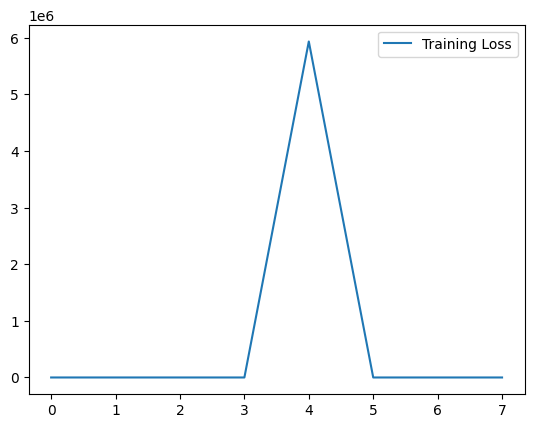

In [119]:
plt.plot(history_lstm.history["loss"], label="Training Loss")
# plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.legend()
print(ptb_normal_train_data.shape)

In [121]:
# def predict(model, data, threshold):
#   reconstructions = model(data)
#   loss = tf.keras.losses.mae(reconstructions, data)
#   return tf.math.less(loss, threshold)

# def print_stats(predictions, labels):
#   print("Accuracy = {}".format(accuracy_score(labels, predictions)))
#   print("Precision = {}".format(precision_score(labels, predictions)))
#   print("Recall = {}".format(recall_score(labels, predictions)))

# preds3 = predict(autoencoder, test_data, threshold)
# print_stats(preds3, test_labels)



def prediction(model, data):
  reconstructions = model(data)
  reconstructions = tf.reshape(reconstructions, data.shape)
  loss = tf.keras.losses.mean_absolute_error(reconstructions, data)
  return reconstructions.numpy(), loss.numpy()

guess32, training_loss32 = prediction(model_ltsm, ptb_normal_train_data)
print(type(training_loss32))
print(training_loss32)
threshold = np.mean(training_loss32) + np.std(training_loss32)



def evaluate_model_complete(model, data):
    pred, loss = prediction(model, data)
    accuracy_abnormal = 0
    accuracy_normal= 0

    for l in loss:
        if l > threshold:
            accuracy_abnormal += 1
        elif l <= threshold:
            accuracy_normal += 1

    if id(data) == id(ptb_abnormal_data):
        accuracy = accuracy_abnormal/len(data)
    else: 
        accuracy = accuracy_normal/len(data)
    
    # if id(data) == id(ptb_abnormal_data):
    #     accuracy = np.sum(loss > threshold)/len(data)
    # else:
    #     accuracy = np.sum(loss <= threshold)/len(data)
    return f"Accuracy: {accuracy:.2%}"

output = evaluate_model_complete(model_ltsm, ptb_normal_train_data)
output2 = evaluate_model_complete(model_ltsm, normal_test3)
output3 = evaluate_model_complete(model_ltsm, ptb_abnormal_data)
print(output, output2, output3)

<class 'numpy.ndarray'>
[0.18623271 0.15788683 0.08645233 ... 0.17363973 0.14692293 0.29844102]
Accuracy: 84.61% Accuracy: 83.70% Accuracy: 33.80%
